In [1]:
import tqdm, tifffile
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

from constants import MODALITY_ALIGNMENT, MODALITY_PREPROCESSING, ModalityType


In [2]:
PATH = "/staging/leuven/stg_00077/projects/jelle/lipogrid/pilot/MALDI_MSI/d_lipogrid"
REFERENCE_MODALITY_NAME = 'Xenium'
TARGET_MODALITY_NAME = 'MSI'
SAMPLE_ID = "20250606_RUN01_01"
REFERENCE_MODALITY_TYPE = ModalityType.ST
TARGET_MODALITY_TYPE = ModalityType.MSI

In [3]:
# Load the Reference Modality
if REFERENCE_MODALITY_TYPE in [ModalityType.MICROSCOPY_IMAGE, ModalityType.RAMAN]:
    reference_image_path = MODALITY_PREPROCESSING(PATH, SAMPLE_ID, REFERENCE_MODALITY_NAME, "ome.tiff")
    with tifffile.TiffFile(reference_image_path) as tif:
        reference_payload = tif.asarray()

    reference_payload = reference_payload.transpose(1, 2, 0)  # Convert from CHW to HWC format
    reference_payload = np.mean(reference_payload, axis=2)  # Convert to grayscale by averaging channels

    print(f"Reference modality of type {REFERENCE_MODALITY_TYPE} has shape: {reference_payload.shape}")
elif REFERENCE_MODALITY_TYPE in [ModalityType.ST, ModalityType.MSI]:
    reference_anndata_path = MODALITY_PREPROCESSING(PATH, SAMPLE_ID, REFERENCE_MODALITY_NAME, "h5ad")
    reference_payload = ad.read_h5ad(reference_anndata_path)
    print(f"Reference modality of type {REFERENCE_MODALITY_TYPE} has shape: {reference_payload.shape}")

Reference modality of type st has shape: (15111, 541)


In [4]:
# Load the Target modality AnnData
if TARGET_MODALITY_TYPE in [ModalityType.MICROSCOPY_IMAGE, ModalityType.RAMAN]:
    target_image_path = MODALITY_ALIGNMENT(PATH, SAMPLE_ID, TARGET_MODALITY_NAME, "ome.tiff")
    with tifffile.TiffFile(target_image_path) as tif:
        target_payload = tif.asarray()

    target_payload = target_payload.transpose(1, 2, 0)  # Convert from CHW to HWC format
    target_payload = np.mean(target_payload, axis=2)  # Convert to grayscale by averaging channels

    print(f"Target modality of type {TARGET_MODALITY_TYPE} has shape: {target_payload.shape}")
elif TARGET_MODALITY_TYPE in [ModalityType.ST, ModalityType.MSI]:
    target_anndata_path = MODALITY_ALIGNMENT(PATH, SAMPLE_ID, TARGET_MODALITY_NAME, "h5ad")
    target_payload = ad.read_h5ad(target_anndata_path)
    print(f"Target modality of type {TARGET_MODALITY_TYPE} has shape: {target_payload.shape}")

Target modality of type msi has shape: (258000, 7420)


In [5]:
# Keep only the foreground for the target modality
if TARGET_MODALITY_TYPE in [ModalityType.ST, ModalityType.MSI]:
    target_mask = target_payload.obs['foreground'].values
    target_payload = target_payload[target_mask].copy()
    print(f"Target modality after foreground filtering has shape: {target_payload.shape}")

Target modality after foreground filtering has shape: (8371, 7420)


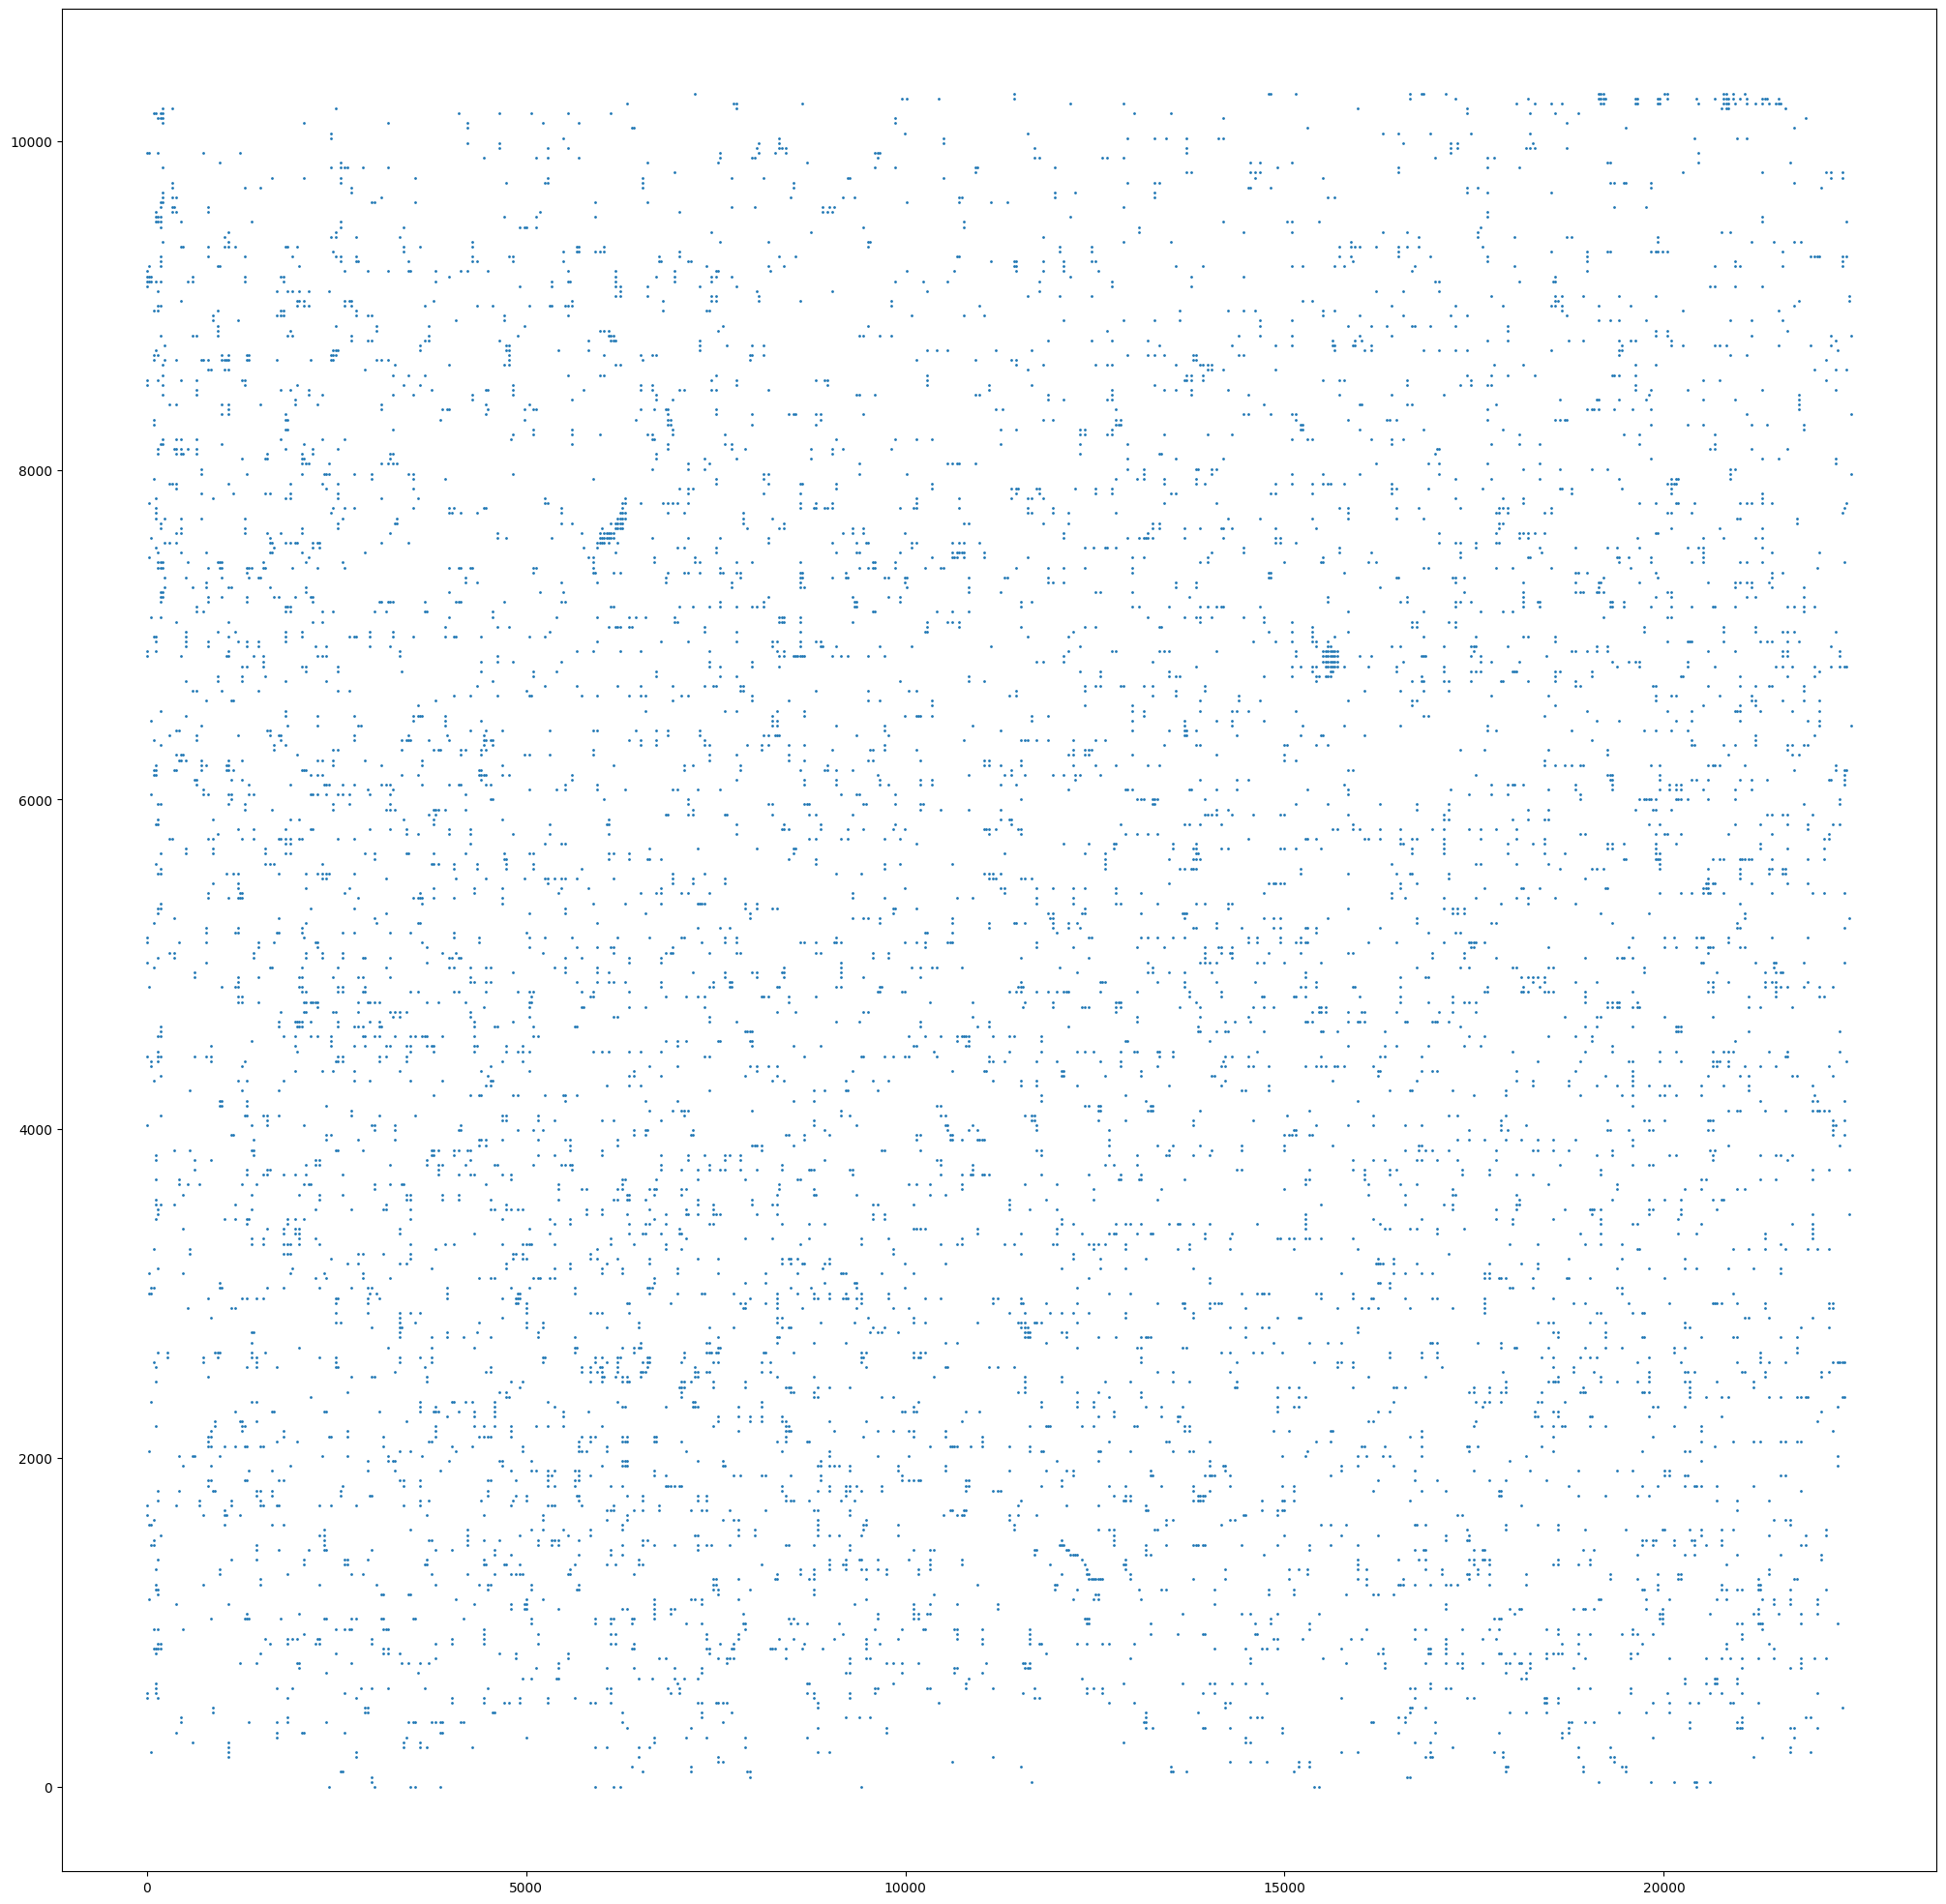

In [12]:
plt.figure(figsize=(25, 25))
plt.scatter(target_payload.obsm['spatial'][:, 0], target_payload.obsm['spatial'][:, 1], s=1)

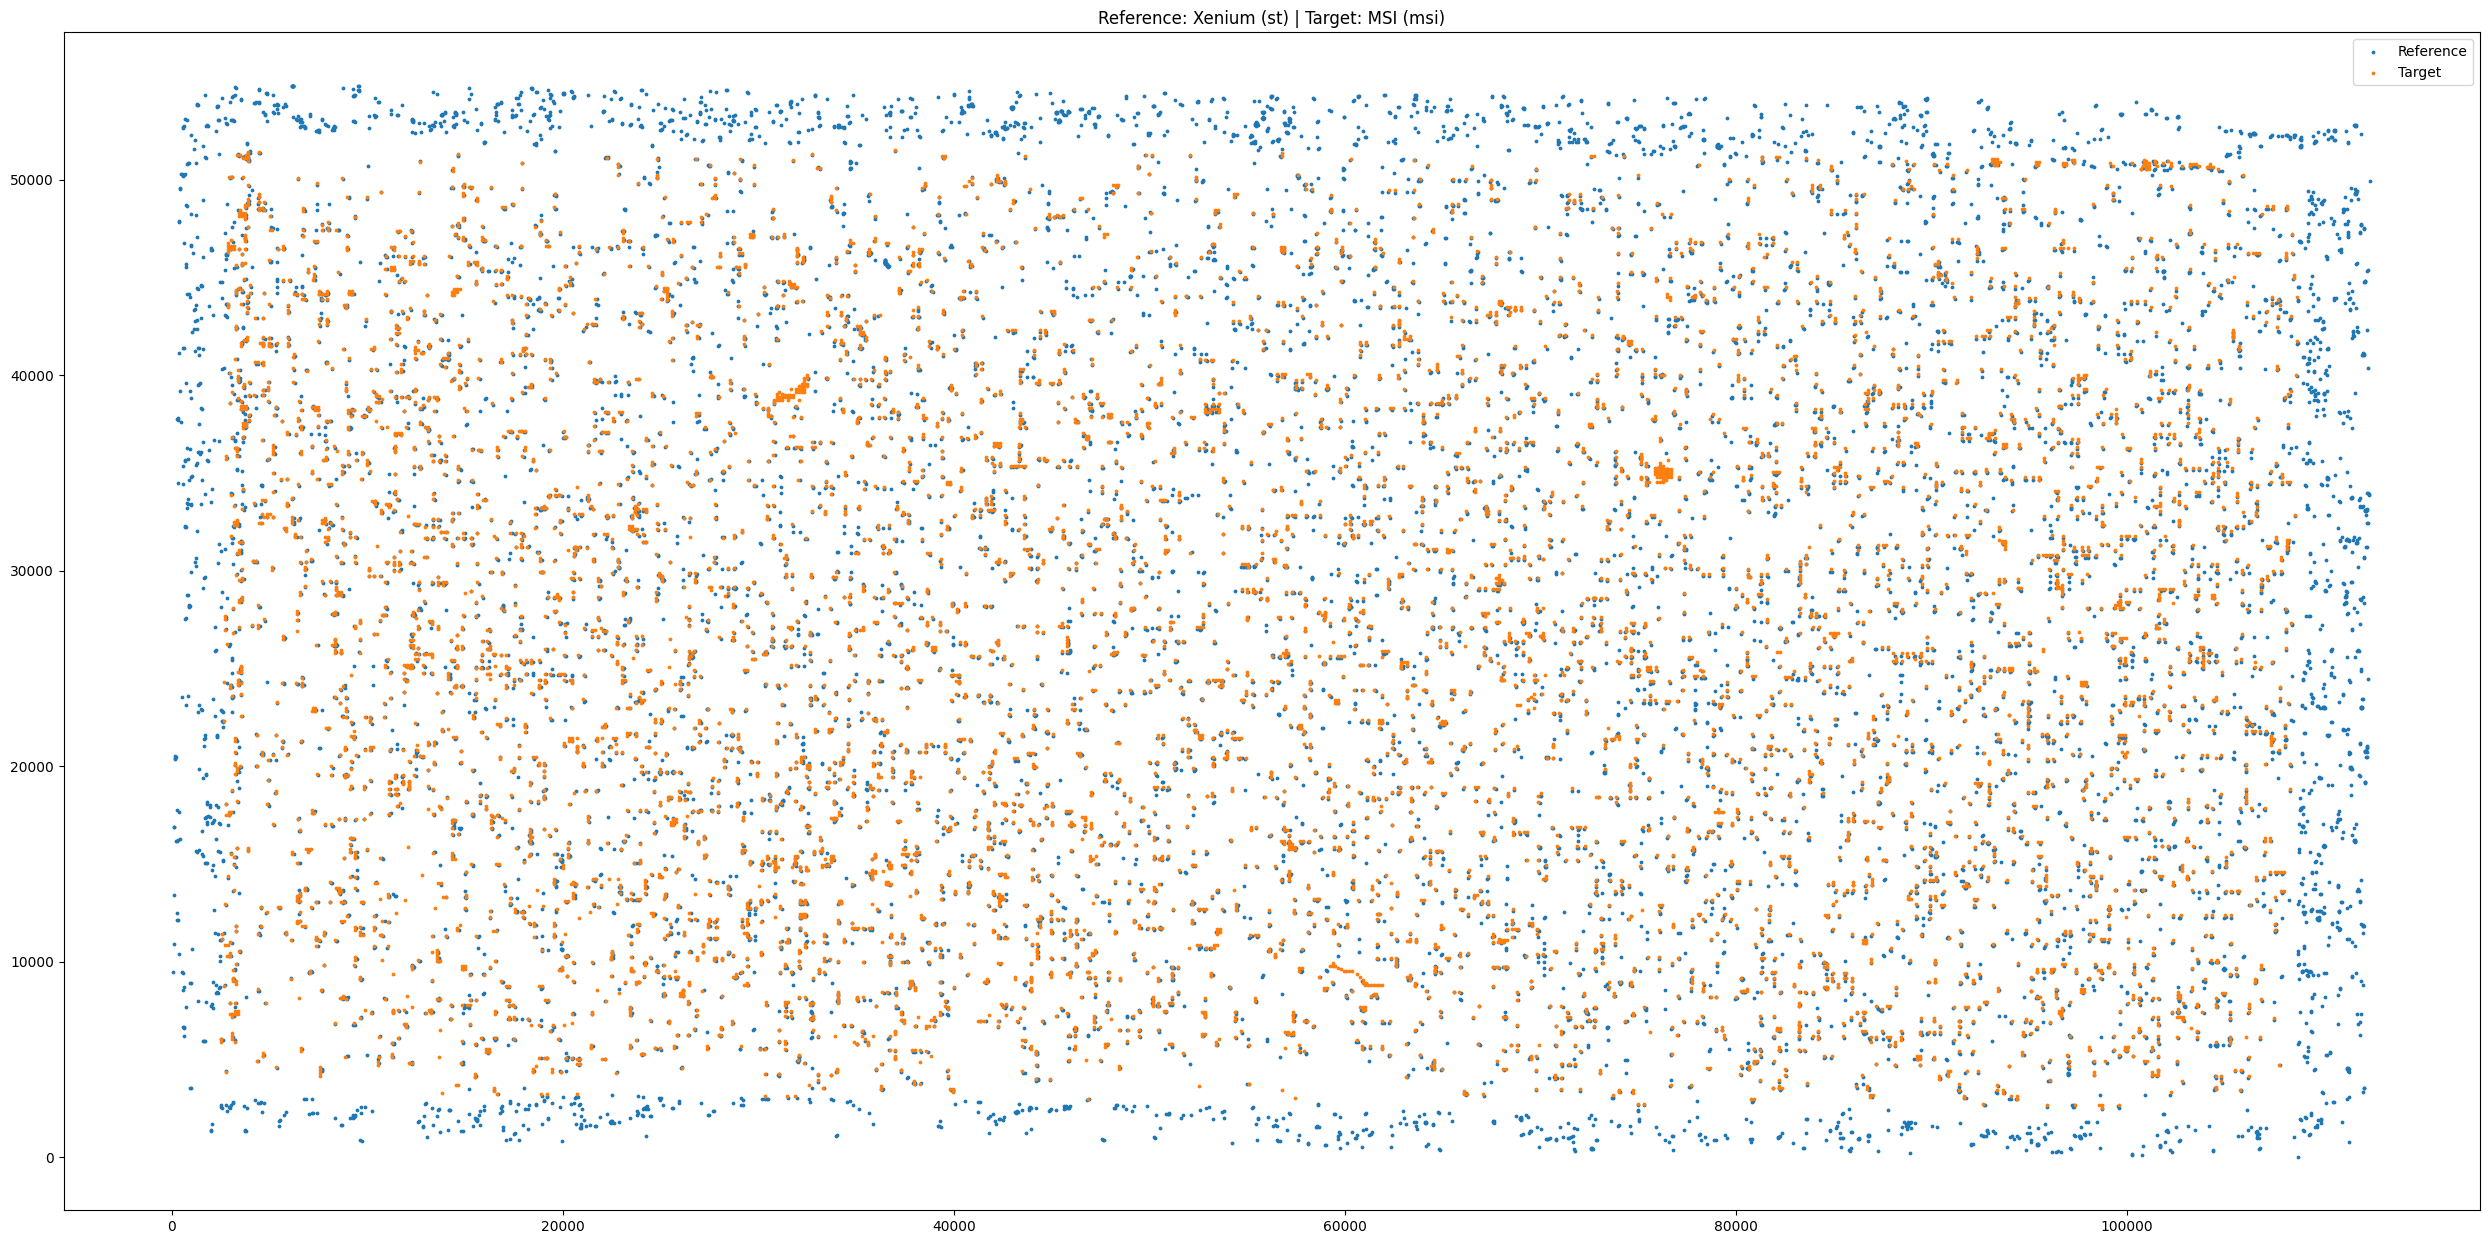

In [11]:
fig, ax = plt.subplots(figsize=(25, 25))

# Common title
ax.set_title(
    f"Reference: {REFERENCE_MODALITY_NAME} ({REFERENCE_MODALITY_TYPE}) | "
    f"Target: {TARGET_MODALITY_NAME} ({TARGET_MODALITY_TYPE})"
)

# Reference
if REFERENCE_MODALITY_TYPE in [ModalityType.MICROSCOPY_IMAGE, ModalityType.RAMAN]:
    ax.imshow(reference_payload, cmap="gray")  # aspect='equal' by default for images [web:10]
elif REFERENCE_MODALITY_TYPE in [ModalityType.ST, ModalityType.MSI]:
    coords = reference_payload.obsm["spatial"]
    ax.scatter(coords[:, 0], coords[:, 1], s=3, c="C0", label="Reference")

# Target (overlaid)
if TARGET_MODALITY_TYPE in [ModalityType.MICROSCOPY_IMAGE, ModalityType.RAMAN]:
    # Use alpha to see both if you overlay two images
    ax.imshow(target_payload, cmap="magma", alpha=0.4)
elif TARGET_MODALITY_TYPE in [ModalityType.ST, ModalityType.MSI]:
    coords_t = target_payload.obsm[f"{REFERENCE_MODALITY_NAME}_spatial"]
    ax.scatter(coords_t[:, 0], coords_t[:, 1], s=3, c="C1", label="Target")

# Enforce equal aspect so scatter is not distorted
ax.set_aspect("equal", adjustable="box")  # keeps x/y units equal while using available box [web:3][web:14]

# Optional: common limits and legend
ax.autoscale()  # ensure limits cover all data
if any(t in [ModalityType.ST, ModalityType.MSI] for t in [REFERENCE_MODALITY_TYPE, TARGET_MODALITY_TYPE]):
    ax.legend(loc="best")

plt.tight_layout()
plt.show()